# Predicting Professional Tennis Match Outcomes with Machine Learning

## 1. Settings

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)

START_YEAR = 2010
END_YEAR = 2024

DATA_URL = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/atp_matches_{year}.csv"

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## 2. Download and Load the Data

This downloads the yearly ATP files. If the file already exists locally, the notebook uses the local copy.

In [3]:
all_years = []

for year in range(START_YEAR, END_YEAR + 1):
    local_file = RAW_DIR / f"atp_matches_{year}.csv"
    url = DATA_URL.format(year=year)

    if local_file.exists():
        year_data = pd.read_csv(local_file)
    else:
        year_data = pd.read_csv(url)
        year_data.to_csv(local_file, index=False)

    year_data["source_year"] = year
    all_years.append(year_data)

matches = pd.concat(all_years, ignore_index=True)

print(matches.shape)
matches.head()

(42571, 50)


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,source_year
0,2010-339,Brisbane,Hard,32,A,20100103,1,104053,1.0,NaN,Andy Roddick,R,188.0,USA,27.3,103429,NaN,NaN,Peter Luczak,R,183.0,AUS,30.3,7-6(5) 6-2,3,R32,84.0,15.0,0.0,63.0,42.0,36.0,14.0,10.0,3.0,3.0,4.0,2.0,56.0,34.0,29.0,11.0,10.0,3.0,5.0,7.0,4410.0,77.0,598.0,2010
1,2010-339,Brisbane,Hard,32,A,20100103,2,104958,NaN,WC,Carsten Ball,L,198.0,AUS,22.5,104999,NaN,NaN,Mischa Zverev,L,190.0,GER,22.3,7-5 6-1,3,R32,70.0,10.0,3.0,57.0,30.0,23.0,19.0,10.0,0.0,0.0,2.0,2.0,66.0,34.0,22.0,14.0,9.0,7.0,10.0,134.0,400.0,78.0,590.0,2010
2,2010-339,Brisbane,Hard,32,A,20100103,3,104755,NaN,NaN,Richard Gasquet,R,185.0,FRA,23.5,103813,NaN,NaN,Jarkko Nieminen,L,185.0,FIN,28.4,6-3 4-6 6-4,3,R32,121.0,5.0,4.0,97.0,51.0,33.0,27.0,15.0,5.0,8.0,4.0,0.0,85.0,58.0,38.0,14.0,14.0,7.0,11.0,52.0,850.0,88.0,568.0,2010
3,2010-339,Brisbane,Hard,32,A,20100103,4,105051,NaN,Q,Matthew Ebden,R,188.0,AUS,22.1,103781,6.0,NaN,Jurgen Melzer,L,183.0,AUT,28.6,7-5 6-1,3,R32,64.0,12.0,1.0,50.0,35.0,30.0,12.0,10.0,3.0,3.0,2.0,1.0,53.0,29.0,16.0,15.0,9.0,2.0,5.0,285.0,151.0,28.0,1260.0,2010
4,2010-339,Brisbane,Hard,32,A,20100103,5,104607,4.0,NaN,Tomas Berdych,R,196.0,CZE,24.2,105194,NaN,Q,Nick Lindahl,R,183.0,AUS,21.4,6-2 6-4,3,R32,69.0,3.0,1.0,46.0,27.0,24.0,14.0,9.0,1.0,1.0,6.0,1.0,69.0,41.0,26.0,14.0,9.0,6.0,9.0,20.0,1655.0,251.0,179.0,2010


## 3. Keep the Columns We Need

We are keeping basic match information and pre-match information like ranking, ranking points, and age. We are not using same-match serving stats yet because those would not be known before predicting a match.

In [4]:
columns_to_keep = [
    "tourney_id",
    "tourney_name",
    "surface",
    "tourney_date",
    "match_num",
    "best_of",
    "round",
    "winner_id",
    "winner_name",
    "winner_age",
    "loser_id",
    "loser_name",
    "loser_age",
    "winner_rank",
    "winner_rank_points",
    "loser_rank",
    "loser_rank_points",
    "source_year",
]

matches = matches[columns_to_keep].copy()

matches.head()

,tourney_id,tourney_name,surface,tourney_date,match_num,best_of,round,winner_id,winner_name,winner_age,loser_id,loser_name,loser_age,winner_rank,winner_rank_points,loser_rank,loser_rank_points,source_year
0,2010-339,Brisbane,Hard,20100103,1,3,R32,104053,Andy Roddick,27.3,103429,Peter Luczak,30.3,7.0,4410.0,77.0,598.0,2010
1,2010-339,Brisbane,Hard,20100103,2,3,R32,104958,Carsten Ball,22.5,104999,Mischa Zverev,22.3,134.0,400.0,78.0,590.0,2010
2,2010-339,Brisbane,Hard,20100103,3,3,R32,104755,Richard Gasquet,23.5,103813,Jarkko Nieminen,28.4,52.0,850.0,88.0,568.0,2010
3,2010-339,Brisbane,Hard,20100103,4,3,R32,105051,Matthew Ebden,22.1,103781,Jurgen Melzer,28.6,285.0,151.0,28.0,1260.0,2010
4,2010-339,Brisbane,Hard,20100103,5,3,R32,104607,Tomas Berdych,24.2,105194,Nick Lindahl,21.4,20.0,1655.0,251.0,179.0,2010


## 4. Basic Cleaning

In [5]:
matches["match_date"] = pd.to_datetime(
    matches["tourney_date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

number_columns = [
    "winner_age",
    "loser_age",
    "winner_rank",
    "loser_rank",
    "winner_rank_points",
    "loser_rank_points",
]

for column in number_columns:
    matches[column] = pd.to_numeric(matches[column], errors="coerce")

cleaned = matches.dropna(
    subset=["match_date", "winner_id", "loser_id", "winner_rank", "loser_rank"]
).copy()

print("Original rows:", len(matches))
print("Rows after basic cleaning:", len(cleaned))
cleaned.head()

Original rows: 42571
Rows after basic cleaning: 41750


,tourney_id,tourney_name,surface,tourney_date,match_num,best_of,round,winner_id,winner_name,winner_age,loser_id,loser_name,loser_age,winner_rank,winner_rank_points,loser_rank,loser_rank_points,source_year,match_date
0,2010-339,Brisbane,Hard,20100103,1,3,R32,104053,Andy Roddick,27.3,103429,Peter Luczak,30.3,7.0,4410.0,77.0,598.0,2010,2010-01-03
1,2010-339,Brisbane,Hard,20100103,2,3,R32,104958,Carsten Ball,22.5,104999,Mischa Zverev,22.3,134.0,400.0,78.0,590.0,2010,2010-01-03
2,2010-339,Brisbane,Hard,20100103,3,3,R32,104755,Richard Gasquet,23.5,103813,Jarkko Nieminen,28.4,52.0,850.0,88.0,568.0,2010,2010-01-03
3,2010-339,Brisbane,Hard,20100103,4,3,R32,105051,Matthew Ebden,22.1,103781,Jurgen Melzer,28.6,285.0,151.0,28.0,1260.0,2010,2010-01-03
4,2010-339,Brisbane,Hard,20100103,5,3,R32,104607,Tomas Berdych,24.2,105194,Nick Lindahl,21.4,20.0,1655.0,251.0,179.0,2010,2010-01-03


## 5. Starter Feature Engineering

These features are simple and easy to explain. Since the data is still in winner/loser format, these are mostly useful for early exploration and for building a ranking baseline later.

In [6]:
cleaned["ranking_diff"] = cleaned["winner_rank"] - cleaned["loser_rank"]
cleaned["rank_points_diff"] = cleaned["winner_rank_points"] - cleaned["loser_rank_points"]
cleaned["age_diff"] = cleaned["winner_age"] - cleaned["loser_age"]
cleaned["higher_ranked_won"] = (cleaned["winner_rank"] < cleaned["loser_rank"]).astype(int)
cleaned["match_year"] = cleaned["match_date"].dt.year

cleaned[[
    "match_date",
    "surface",
    "winner_name",
    "loser_name",
    "winner_rank",
    "loser_rank",
    "ranking_diff",
    "higher_ranked_won",
]].head()

,match_date,surface,winner_name,loser_name,winner_rank,loser_rank,ranking_diff,higher_ranked_won
0,2010-01-03,Hard,Andy Roddick,Peter Luczak,7.0,77.0,-70.0,1
1,2010-01-03,Hard,Carsten Ball,Mischa Zverev,134.0,78.0,56.0,0
2,2010-01-03,Hard,Richard Gasquet,Jarkko Nieminen,52.0,88.0,-36.0,1
3,2010-01-03,Hard,Matthew Ebden,Jurgen Melzer,285.0,28.0,257.0,0
4,2010-01-03,Hard,Tomas Berdych,Nick Lindahl,20.0,251.0,-231.0,1


## 6. Quick Checks

In [7]:
cleaned.isna().mean().sort_values(ascending=False).head(10)

surface              0.000862
tourney_id           0.000000
winner_rank          0.000000
higher_ranked_won    0.000000
age_diff             0.000000
rank_points_diff     0.000000
ranking_diff         0.000000
match_date           0.000000
source_year          0.000000
loser_rank_points    0.000000
dtype: float64

In [8]:
cleaned.groupby("match_year").size().tail()

match_year
2020    1418
2021    2705
2022    2893
2023    2940
2024    3030
dtype: int64

In [9]:
cleaned["surface"].value_counts(dropna=False)

surface
Hard      24294
Clay      12894
Grass      4476
Carpet       50
NaN          36
Name: count, dtype: int64

In [10]:
higher_ranked_win_rate = cleaned["higher_ranked_won"].mean()
print(f"Higher-ranked player won {higher_ranked_win_rate:.1%} of matches.")

Higher-ranked player won 65.7% of matches.


## 7. Simple Visualization

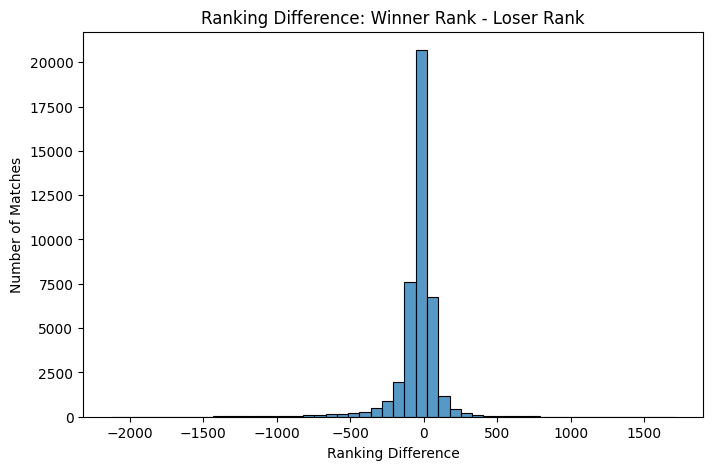

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned["ranking_diff"], bins=50)
plt.title("Ranking Difference: Winner Rank - Loser Rank")
plt.xlabel("Ranking Difference")
plt.ylabel("Number of Matches")
plt.show()

## 8. Save Processed Files

In [12]:
combined_path = PROCESSED_DIR / "atp_matches_combined.csv"
cleaned_path = PROCESSED_DIR / "atp_matches_cleaned_starter.csv"

matches.to_csv(combined_path, index=False)
cleaned.to_csv(cleaned_path, index=False)

print("Saved:", combined_path)
print("Saved:", cleaned_path)

Saved: /Users/mchiu/Documents/GitHub/CS439-Project/data/processed/atp_matches_combined.csv
Saved: /Users/mchiu/Documents/GitHub/CS439-Project/data/processed/atp_matches_cleaned_starter.csv


## 9. Modeling Goal and Evaluation Plan

We want to see if pre-match factors can predict the winner better than a ranking-only rule. The original data is stored from the winner's perspective, so the modeling data below rewrites each match as Player 1 vs. Player 2 and randomly flips which real player is Player 1. That keeps the target honest: "player_1_won" is 1 when Player 1 won and 0 when Player 2 won.

We compare every model to a baseline that always picks the higher-ranked player. Cross-validation is time-aware, so each validation fold is later in the tennis calendar than its training fold.

In [13]:
import numpy as np
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, make_scorer, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 211
N_SPLITS = 5
RECENT_WINDOW = 10

## 10. Build Leakage-Safe Pre-Match Features

These features use only information that would have been available before a match started: rankings, ranking points, ages, surface, round, match format, and each player's prior win rates. Same-match serve and return statistics are intentionally excluded because those are only known after the match.

In [14]:
def add_player_history_features(match_data, recent_window=10):
    ordered = match_data.sort_values(
        ["match_date", "tourney_id", "match_num"],
        kind="mergesort"
    ).reset_index(drop=True).copy()
    ordered["match_id"] = ordered.index

    winner_rows = ordered[[
        "match_id", "match_date", "tourney_id", "match_num", "surface",
        "winner_id", "winner_rank", "winner_rank_points", "winner_age"
    ]].rename(columns={
        "winner_id": "player_id",
        "winner_rank": "player_rank",
        "winner_rank_points": "player_rank_points",
        "winner_age": "player_age",
    })
    winner_rows["won"] = 1

    loser_rows = ordered[[
        "match_id", "match_date", "tourney_id", "match_num", "surface",
        "loser_id", "loser_rank", "loser_rank_points", "loser_age"
    ]].rename(columns={
        "loser_id": "player_id",
        "loser_rank": "player_rank",
        "loser_rank_points": "player_rank_points",
        "loser_age": "player_age",
    })
    loser_rows["won"] = 0

    player_rows = pd.concat([winner_rows, loser_rows], ignore_index=True)
    player_rows = player_rows.sort_values(
        ["match_date", "tourney_id", "match_num", "match_id", "won"],
        kind="mergesort"
    ).reset_index(drop=True)

    player_group = player_rows.groupby("player_id", sort=False)
    player_rows["matches_before"] = player_group.cumcount()
    player_rows["wins_before"] = player_group["won"].cumsum() - player_rows["won"]
    player_rows["career_win_rate_before"] = (
        player_rows["wins_before"] / player_rows["matches_before"]
    ).fillna(0.5)

    player_rows["recent_wins_before"] = player_group["won"].transform(
        lambda values: values.shift().rolling(recent_window, min_periods=1).sum()
    )
    player_rows["recent_matches_before"] = player_group["won"].transform(
        lambda values: values.shift().rolling(recent_window, min_periods=1).count()
    )
    player_rows["recent_win_rate_before"] = (
        player_rows["recent_wins_before"] / player_rows["recent_matches_before"]
    ).fillna(0.5)

    surface_group = player_rows.groupby(["player_id", "surface"], sort=False)
    player_rows["surface_matches_before"] = surface_group.cumcount()
    player_rows["surface_wins_before"] = surface_group["won"].cumsum() - player_rows["won"]
    player_rows["surface_win_rate_before"] = (
        player_rows["surface_wins_before"] / player_rows["surface_matches_before"]
    ).fillna(0.5)

    return ordered, player_rows


ordered_matches, player_history = add_player_history_features(cleaned, RECENT_WINDOW)
player_history.head()

,match_id,match_date,tourney_id,match_num,surface,player_id,player_rank,player_rank_points,player_age,won,matches_before,wins_before,career_win_rate_before,recent_wins_before,recent_matches_before,recent_win_rate_before,surface_matches_before,surface_wins_before,surface_win_rate_before
0,0,2010-01-03,2010-339,1,Hard,103429,77.0,598.0,30.3,0,0,0,0.5,NaN,0.0,0.5,0.0,0.0,0.5
1,0,2010-01-03,2010-339,1,Hard,104053,7.0,4410.0,27.3,1,0,0,0.5,NaN,0.0,0.5,0.0,0.0,0.5
2,1,2010-01-03,2010-339,2,Hard,104999,78.0,590.0,22.3,0,0,0,0.5,NaN,0.0,0.5,0.0,0.0,0.5
3,1,2010-01-03,2010-339,2,Hard,104958,134.0,400.0,22.5,1,0,0,0.5,NaN,0.0,0.5,0.0,0.0,0.5
4,2,2010-01-03,2010-339,3,Hard,103813,88.0,568.0,28.4,0,0,0,0.5,NaN,0.0,0.5,0.0,0.0,0.5


In [15]:
def make_modeling_table(match_data, player_history, random_state=RANDOM_STATE):
    rng = pd.Series(
        np.random.default_rng(random_state).integers(0, 2, size=len(match_data)),
        index=match_data["match_id"].to_numpy(),
        name="flip_players"
    )

    player_features = [
        "match_id",
        "player_id",
        "player_rank",
        "player_rank_points",
        "player_age",
        "matches_before",
        "career_win_rate_before",
        "recent_win_rate_before",
        "surface_win_rate_before",
        "won",
    ]

    winners = player_history.loc[player_history["won"] == 1, player_features].set_index("match_id")
    losers = player_history.loc[player_history["won"] == 0, player_features].set_index("match_id")

    rows = match_data.set_index("match_id")[[
        "match_date", "tourney_name", "surface", "round", "best_of", "winner_name", "loser_name"
    ]].copy()
    rows["flip_players"] = rng

    for column in player_features:
        if column == "match_id":
            continue
        rows[f"winner_{column}"] = winners[column]
        rows[f"loser_{column}"] = losers[column]

    player_columns = [
        "player_id",
        "player_rank",
        "player_rank_points",
        "player_age",
        "matches_before",
        "career_win_rate_before",
        "recent_win_rate_before",
        "surface_win_rate_before",
    ]

    for column in player_columns:
        rows[f"p1_{column}"] = np.where(
            rows["flip_players"].eq(0),
            rows[f"winner_{column}"],
            rows[f"loser_{column}"]
        )
        rows[f"p2_{column}"] = np.where(
            rows["flip_players"].eq(0),
            rows[f"loser_{column}"],
            rows[f"winner_{column}"]
        )

    rows["player_1_won"] = rows["flip_players"].eq(0).astype(int)
    rows["match_year"] = rows["match_date"].dt.year

    rows["rank_diff"] = rows["p1_player_rank"] - rows["p2_player_rank"]
    rows["rank_points_diff"] = rows["p1_player_rank_points"] - rows["p2_player_rank_points"]
    rows["age_diff"] = rows["p1_player_age"] - rows["p2_player_age"]
    rows["experience_diff"] = rows["p1_matches_before"] - rows["p2_matches_before"]
    rows["career_win_rate_diff"] = rows["p1_career_win_rate_before"] - rows["p2_career_win_rate_before"]
    rows["recent_win_rate_diff"] = rows["p1_recent_win_rate_before"] - rows["p2_recent_win_rate_before"]
    rows["surface_win_rate_diff"] = rows["p1_surface_win_rate_before"] - rows["p2_surface_win_rate_before"]

    return rows.reset_index()


modeling = make_modeling_table(ordered_matches, player_history)

modeling[[
    "match_date", "surface", "round", "winner_name", "loser_name",
    "flip_players", "rank_diff", "recent_win_rate_diff", "player_1_won"
]].head()

,match_date,surface,round,winner_name,loser_name,flip_players,rank_diff,recent_win_rate_diff,player_1_won
0,2010-01-03,Hard,R32,Andy Roddick,Peter Luczak,0,-70.0,0.0,1
1,2010-01-03,Hard,R32,Carsten Ball,Mischa Zverev,0,56.0,0.0,1
2,2010-01-03,Hard,R32,Richard Gasquet,Jarkko Nieminen,0,-36.0,0.0,1
3,2010-01-03,Hard,R32,Matthew Ebden,Jurgen Melzer,0,257.0,0.0,1
4,2010-01-03,Hard,R32,Tomas Berdych,Nick Lindahl,1,231.0,0.0,0


## 11. Cross-Validation Setup

The validation uses "TimeSeriesSplit" to train on earlier matches and test on later matches. This is stricter than random folds and better matches the real prediction task, where we would use the past to predict future matches.

In [16]:
numeric_features = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "experience_diff",
    "career_win_rate_diff",
    "recent_win_rate_diff",
    "surface_win_rate_diff",
    "p1_player_rank",
    "p2_player_rank",
    "p1_player_rank_points",
    "p2_player_rank_points",
    "p1_player_age",
    "p2_player_age",
    "p1_matches_before",
    "p2_matches_before",
    "match_year",
]

categorical_features = ["surface", "round", "best_of"]
feature_columns = numeric_features + categorical_features

modeling = modeling.sort_values("match_date", kind="mergesort").reset_index(drop=True)
X = modeling[feature_columns].copy()
y = modeling["player_1_won"].astype(int).copy()

cv = TimeSeriesSplit(n_splits=N_SPLITS)

print("Modeling rows:", len(modeling))
print("Target balance:")
print(y.value_counts(normalize=True).rename("share"))

Modeling rows: 41750
Target balance:
player_1_won
0    0.501126
1    0.498874
Name: share, dtype: float64


In [17]:
def build_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ])


models = {
    "Logistic Regression": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=True)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False)),
        ("model", RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=10,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False)),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}


## 12. Ranking Baseline

This baseline predicts that the player with the better ATP rank wins, where rank 1 is better than rank 10. If the two ranks are tied, the rule makes an arbitrary Player 2 prediction.

In [18]:
def evaluate_ranking_baseline(X, y, cv):
    fold_scores = []

    for fold, (_, test_index) in enumerate(cv.split(X), start=1):
        X_test = X.iloc[test_index]
        y_test = y.iloc[test_index]

        y_pred = (X_test["rank_diff"] < 0).astype(int)
        y_score = -X_test["rank_diff"]

        fold_scores.append({
            "model": "Higher-Ranked Baseline",
            "fold": fold,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score),
        })

    return pd.DataFrame(fold_scores)


baseline_fold_scores = evaluate_ranking_baseline(X, y, cv)
baseline_fold_scores


,model,fold,accuracy,balanced_accuracy,f1,precision,recall,roc_auc
0,Higher-Ranked Baseline,1,0.672032,0.672031,0.673253,0.674219,0.672291,0.712792
1,Higher-Ranked Baseline,2,0.680224,0.680222,0.683364,0.686392,0.680363,0.718229
2,Higher-Ranked Baseline,3,0.636821,0.636827,0.636664,0.634748,0.638592,0.673202
3,Higher-Ranked Baseline,4,0.637108,0.637088,0.640160,0.636802,0.643553,0.677373
4,Higher-Ranked Baseline,5,0.637396,0.637551,0.636088,0.626598,0.645870,0.668463


## 13. Compare Models With Cross-Validation

In [19]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "roc_auc": "roc_auc",
}

model_fold_scores = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    fold_result = pd.DataFrame({
        "model": model_name,
        "fold": range(1, N_SPLITS + 1),
        "accuracy": scores["test_accuracy"],
        "balanced_accuracy": scores["test_balanced_accuracy"],
        "f1": scores["test_f1"],
        "precision": scores["test_precision"],
        "recall": scores["test_recall"],
        "roc_auc": scores["test_roc_auc"],
    })
    model_fold_scores.append(fold_result)

all_fold_scores = pd.concat([baseline_fold_scores, *model_fold_scores], ignore_index=True)

cv_results = (
    all_fold_scores
    .groupby("model")[["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]]
    .agg(["mean", "std"])
    .sort_values(("accuracy", "mean"), ascending=False)
)

cv_results


accuracy           balanced_accuracy            \
                            mean       std              mean       std   
model                                                                    
Random Forest           0.666916  0.022338          0.666876  0.022380   
Logistic Regression     0.659759  0.022190          0.659729  0.022166   
Gradient Boosting       0.655936  0.012473          0.655856  0.012330   
Higher-Ranked Baseline  0.652716  0.021568          0.652744  0.021542   

                              f1           precision              recall  \
                            mean       std      mean       std      mean   
model                                                                      
Random Forest           0.669755  0.022712  0.664440  0.028861  0.675492   
Logistic Regression     0.661739  0.022644  0.658126  0.027772  0.665569   
Gradient Boosting       0.658957  0.017097  0.653566  0.020820  0.665573   
Higher-Ranked Baseline  0.653906  0.022615  0.651752  0.026693  0.656134   

                                   roc_auc            
                             std      mean       std  
model                                                 
Random Forest           0.021558  0.732242  0.025351  
Logistic Regression     0.019963  0.724135  0.025293  
Gradient Boosting       0.033276  0.721214  0.014844  
Higher-Ranked Baseline  0.018837  0.690012  0.023568

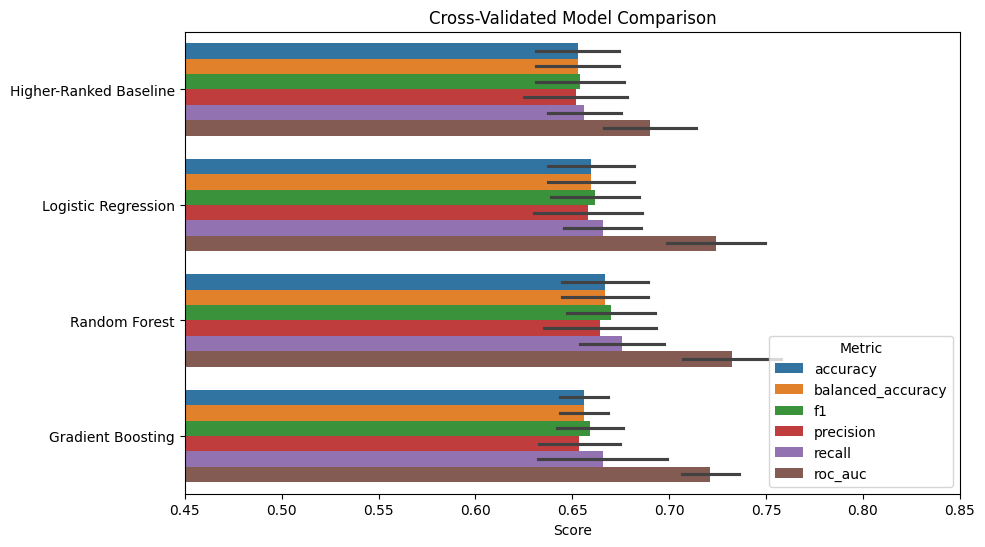

In [20]:
summary_for_plot = all_fold_scores.melt(
    id_vars=["model", "fold"],
    value_vars=["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_for_plot,
    x="score",
    y="model",
    hue="metric",
    errorbar="sd"
)
plt.title("Cross-Validated Model Comparison")
plt.xlabel("Score")
plt.ylabel("")
plt.xlim(0.45, 0.85)
plt.legend(title="Metric", loc="lower right")
plt.show()


## 14. Choose the Best Model

The project decision is based first on cross-validated accuracy, with ROC AUC used as a secondary check. Precision and recall are also shown because they reveal whether a model is better at identifying Player 1 wins or is simply leaning toward one side of the randomized matchup. The baseline remains in the table because it is the model every learned method needs to beat.


In [21]:
ranking_table = (
    all_fold_scores
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        f1_mean=("f1", "mean"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
    )
    .sort_values(["accuracy_mean", "roc_auc_mean"], ascending=False)
)

best_overall_name = ranking_table.index[0]
best_learned_name = ranking_table.drop(index="Higher-Ranked Baseline", errors="ignore").index[0]

print("Best overall:", best_overall_name)
print("Best learned model:", best_learned_name)

ranking_table

Best overall: Random Forest
Best learned model: Random Forest


,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean,precision_mean,recall_mean,roc_auc_mean
model,,,,,,,
Random Forest,0.666916,0.022338,0.666876,0.669755,0.664440,0.675492,0.732242
Logistic Regression,0.659759,0.022190,0.659729,0.661739,0.658126,0.665569,0.724135
Gradient Boosting,0.655936,0.012473,0.655856,0.658957,0.653566,0.665573,0.721214
Higher-Ranked Baseline,0.652716,0.021568,0.652744,0.653906,0.651752,0.656134,0.690012


In [22]:
best_learned_model = clone(models[best_learned_name])
best_learned_model.fit(X, y)

if best_overall_name == "Higher-Ranked Baseline":
    print(
        "The ranking-only baseline had the best cross-validated accuracy. "
        f"The strongest trained model was {best_learned_name}, which is still useful for interpretation."
    )
else:
    print(
        f"{best_overall_name} had the best cross-validated accuracy and should be the current project model."
    )


Random Forest had the best cross-validated accuracy and should be the current project model.
